In [ ]:
import cv2
import os
from tqdm import tqdm

# ==============================
# PATHS
# ==============================
DATASET_PATH = "/content/drive/MyDrive/Deepfake dataset/FF++C23"
OUTPUT_PATH = "/content/drive/MyDrive/Deepfake dataset/FF++C23_FRAMES"

FRAME_SKIP = 10

real_in = os.path.join(DATASET_PATH, "original")
fake_in = os.path.join(DATASET_PATH, "Deepfakes") # Corrected 'deepfake' to 'Deepfakes'

real_out = os.path.join(OUTPUT_PATH, "real")
fake_out = os.path.join(OUTPUT_PATH, "fake")

os.makedirs(real_out, exist_ok=True)
os.makedirs(fake_out, exist_ok=True)

# ==============================
# FUNCTION
# ==============================

def extract_frames(input_folder, output_folder):
    for video_name in tqdm(os.listdir(input_folder)):
        if not video_name.endswith(".mp4"):
            continue

        video_id = video_name.split(".")[0]   # 000 OR 000_003
        cap = cv2.VideoCapture(os.path.join(input_folder, video_name))

        frame_id = 0

        while True:
            ret, frame = cap.read()
            if not ret:
                break

            if frame_id % FRAME_SKIP == 0:
                filename = f"{video_id}_{frame_id}.jpg"
                cv2.imwrite(os.path.join(output_folder, filename), frame)

            frame_id += 1

        cap.release()

# ==============================
# RUN
# ==============================

extract_frames(real_in, real_out)
extract_frames(fake_in, fake_out)

print("✅ Frame extraction done")

100%|██████████| 301/301 [23:55<00:00,  4.77s/it]

✅ Frame extraction done


In [ ]:
!pip install mtcnn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 46.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 40.2 MB/s eta 0:00:00


In [ ]:
import os
import cv2
import numpy as np
from tqdm import tqdm
from mtcnn import MTCNN

# ==============================
# PATHS
# ==============================
FRAME_PATH = "/content/drive/MyDrive/Deepfake dataset/FF++C23_FRAMES"

OUTPUT_PATH = "/content/drive/MyDrive/Deepfake dataset/FF++C23_ALIGNED"

real_in = os.path.join(FRAME_PATH, "real")
fake_in = os.path.join(FRAME_PATH, "fake")

real_out = os.path.join(OUTPUT_PATH, "real")
fake_out = os.path.join(OUTPUT_PATH, "fake")

os.makedirs(real_out, exist_ok=True)
os.makedirs(fake_out, exist_ok=True)

# ==============================
# MTCNN
# ==============================
detector = MTCNN()

# ==============================
# ALIGN FUNCTION
# ==============================
def align_face(img, left_eye, right_eye):

    left_eye = np.array(left_eye)
    right_eye = np.array(right_eye)

    dx = right_eye[0] - left_eye[0]
    dy = right_eye[1] - left_eye[1]

    angle = np.degrees(np.arctan2(dy, dx))

    eyes_center = (
        int((left_eye[0] + right_eye[0]) / 2),
        int((left_eye[1] + right_eye[1]) / 2)
    )

    M = cv2.getRotationMatrix2D(eyes_center, angle, 1.0)

    aligned = cv2.warpAffine(
        img,
        M,
        (img.shape[1], img.shape[0]),
        flags=cv2.INTER_CUBIC
    )

    return aligned

# ==============================
# PROCESS FUNCTION
# ==============================
def process_folder(input_folder, output_folder):

    images = [
        f for f in os.listdir(input_folder)
        if f.lower().endswith((".jpg", ".png", ".jpeg"))
    ]

    saved = 0
    failed = 0

    for img_name in tqdm(images):

        img_path = os.path.join(input_folder, img_name)

        img = cv2.imread(img_path)

        if img is None:
            failed += 1
            continue

        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        faces = detector.detect_faces(img_rgb)

        if len(faces) == 0:
            failed += 1
            continue

        # largest face
        face = max(faces, key=lambda x: x["box"][2] * x["box"][3])

        keypoints = face["keypoints"]

        left_eye = keypoints["left_eye"]
        right_eye = keypoints["right_eye"]

        # align image
        aligned = align_face(img, left_eye, right_eye)

        save_path = os.path.join(output_folder, img_name)

        cv2.imwrite(save_path, aligned)

        saved += 1

    print(f"\nSaved : {saved}")
    print(f"Failed: {failed}")

# ==============================
# RUN
# ==============================
process_folder(real_in, real_out)
process_folder(fake_in, fake_out)

print("\n✅ Face alignment completed")

100%|██████████| 15635/15635 [5:46:18<00:00,  1.33s/it]


Saved : 15628
Failed: 7

✅ Face alignment completed


In [ ]:
!pip install mtcnn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 71.6 MB/s eta 0:00:00


In [ ]:
# ==============================
# FACE CROP FROM ALIGNED FRAMES
# ==============================

import os
import cv2
from tqdm import tqdm
from mtcnn import MTCNN

# ==============================
# PATHS
# ==============================
ALIGNED_PATH = "/content/drive/MyDrive/Deepfake dataset/FF++C23_ALIGNED"

OUTPUT_PATH = "/content/drive/MyDrive/Deepfake dataset/FF++C23_ALIGNED_FACES"

IMG_SIZE = 224

real_in = os.path.join(ALIGNED_PATH, "real")
fake_in = os.path.join(ALIGNED_PATH, "fake")

real_out = os.path.join(OUTPUT_PATH, "real")
fake_out = os.path.join(OUTPUT_PATH, "fake")

os.makedirs(real_out, exist_ok=True)
os.makedirs(fake_out, exist_ok=True)

# ==============================
# MTCNN
# ==============================
detector = MTCNN()

# ==============================
# FACE CROP FUNCTION
# ==============================
def crop_faces(input_folder, output_folder):

    images = [
        f for f in os.listdir(input_folder)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    saved = 0
    failed = 0

    for img_name in tqdm(images):

        img_path = os.path.join(input_folder, img_name)

        save_path = os.path.join(output_folder, img_name)

        # skip already processed
        if os.path.exists(save_path):
            continue

        img = cv2.imread(img_path)

        if img is None:
            failed += 1
            continue

        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        faces = detector.detect_faces(img_rgb)

        if len(faces) == 0:
            failed += 1
            continue

        # largest face
        face = max(faces, key=lambda x: x["box"][2] * x["box"][3])

        x, y, w, h = face["box"]

        # avoid negative values
        x = max(0, x)
        y = max(0, y)

        # margin around face
        margin = 30

        x1 = max(0, x - margin)
        y1 = max(0, y - margin)

        x2 = min(img.shape[1], x + w + margin)
        y2 = min(img.shape[0], y + h + margin)

        face_crop = img[y1:y2, x1:x2]

        if face_crop.size == 0:
            failed += 1
            continue

        # resize
        face_crop = cv2.resize(face_crop, (IMG_SIZE, IMG_SIZE))

        cv2.imwrite(save_path, face_crop)

        saved += 1

    print(f"\nSaved : {saved}")
    print(f"Failed: {failed}")

# ==============================
# RUN
# ==============================
#crop_faces(real_in, real_out)
crop_faces(fake_in, fake_out)

print("\n Face cropping completed")

100%|██████████| 15628/15628 [2:48:18<00:00,  1.55it/s]


Saved : 15622
Failed: 6

✅ Face cropping completed


In [2]:
import os
import random
import shutil
from tqdm import tqdm

# ==============================
# PATHS
# ==============================
SOURCE_PATH = "/content/drive/MyDrive/Deepfake dataset/FF++C23_ALIGNED_FACES"
OUTPUT_PATH = "/content/drive/MyDrive/Deepfake dataset/FF++C23_ALIGNED_FACES_10K"

REAL_KEEP = 5000
FAKE_KEEP = 5000
SEED = 42

real_src = os.path.join(SOURCE_PATH, "real")
fake_src = os.path.join(SOURCE_PATH, "fake")

real_out = os.path.join(OUTPUT_PATH, "real")
fake_out = os.path.join(OUTPUT_PATH, "fake")

os.makedirs(real_out, exist_ok=True)
os.makedirs(fake_out, exist_ok=True)

random.seed(SEED)

def reduce_class(src_folder, out_folder, keep_count):
    images = [
        f for f in os.listdir(src_folder)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    print("Available:", len(images))

    selected = random.sample(images, min(keep_count, len(images)))

    for img_name in tqdm(selected):
        src_path = os.path.join(src_folder, img_name)
        out_path = os.path.join(out_folder, img_name)

        if not os.path.exists(out_path):
            shutil.copy2(src_path, out_path)

    print("Selected:", len(selected))

# ==============================
# RUN
# ==============================
print("Reducing REAL...")
reduce_class(real_src, real_out, REAL_KEEP)

print("\nReducing FAKE...")
reduce_class(fake_src, fake_out, FAKE_KEEP)

print("\n✅ 10K reduced face dataset created")

Reducing REAL...
Available: 15690


100%|██████████| 5000/5000 [05:21<00:00, 15.57it/s]


Selected: 5000

Reducing FAKE...
Available: 15622


100%|██████████| 5000/5000 [05:14<00:00, 15.89it/s]

Selected: 5000

✅ 10K reduced face dataset created


In [3]:
#splitting
import os
import random
import shutil
from tqdm import tqdm

# ==============================
# PATHS
# ==============================
SOURCE_PATH = "/content/drive/MyDrive/Deepfake dataset/FF++C23_ALIGNED_FACES_10K"

OUTPUT_PATH = "/content/drive/MyDrive/Deepfake dataset/FF++C23_FACE_10K_SPLIT"

# ==============================
# SPLIT RATIO
# ==============================
TRAIN_RATIO = 0.80
VAL_RATIO   = 0.10
TEST_RATIO  = 0.10

SEED = 42

random.seed(SEED)

# ==============================
# CREATE FOLDERS
# ==============================
splits = ["train", "val", "test"]
classes = ["real", "fake"]

for split in splits:
    for cls in classes:
        os.makedirs(
            os.path.join(OUTPUT_PATH, split, cls),
            exist_ok=True
        )

# ==============================
# SPLIT FUNCTION
# ==============================
def split_dataset(class_name):

    src_folder = os.path.join(SOURCE_PATH, class_name)

    images = [
        f for f in os.listdir(src_folder)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    random.shuffle(images)

    total = len(images)

    train_end = int(total * TRAIN_RATIO)
    val_end   = train_end + int(total * VAL_RATIO)

    train_imgs = images[:train_end]
    val_imgs   = images[train_end:val_end]
    test_imgs  = images[val_end:]

    split_map = {
        "train": train_imgs,
        "val": val_imgs,
        "test": test_imgs
    }

    # ==============================
    # COPY FILES
    # ==============================
    for split_name, split_images in split_map.items():

        out_folder = os.path.join(
            OUTPUT_PATH,
            split_name,
            class_name
        )

        print(f"\nCopying {class_name} → {split_name}")

        for img_name in tqdm(split_images):

            src_path = os.path.join(src_folder, img_name)
            dst_path = os.path.join(out_folder, img_name)

            if not os.path.exists(dst_path):
                shutil.copy2(src_path, dst_path)

    # ==============================
    # REPORT
    # ==============================
    print(f"\n{class_name.upper()} REPORT")
    print("Total :", total)
    print("Train :", len(train_imgs))
    print("Val   :", len(val_imgs))
    print("Test  :", len(test_imgs))


# ==============================
# RUN
# ==============================
split_dataset("real")
split_dataset("fake")

print("\n✅ Dataset splitting completed")


Copying real → train


100%|██████████| 3999/3999 [02:26<00:00, 27.31it/s]



Copying real → val


100%|██████████| 499/499 [00:09<00:00, 51.67it/s]



Copying real → test


...


Copying fake → val


100%|██████████| 500/500 [00:10<00:00, 48.62it/s]



Copying fake → test


100%|██████████| 500/500 [00:10<00:00, 47.81it/s]


FAKE REPORT
Total : 5000
Train : 4000
Val   : 500
Test  : 500

✅ Dataset splitting completed


In [ ]:
import os
import cv2
from tqdm import tqdm
from mtcnn import MTCNN

# ==============================
# PATHS
# ==============================
FACE_SPLIT_PATH = "/content/drive/MyDrive/Deepfake dataset/FF++C23_FACE_10K_SPLIT"
EYE_OUTPUT_PATH = "/content/drive/MyDrive/Deepfake dataset/FF++C23_EYES_10K_SPLIT"

IMG_SIZE = 50

splits = ["train", "val", "test"]
classes = ["real", "fake"]

# ==============================
# CREATE OUTPUT FOLDERS
# ==============================
for split in splits:
    for cls in classes:
        os.makedirs(os.path.join(EYE_OUTPUT_PATH, split, cls), exist_ok=True)

# ==============================
# MTCNN
# ==============================
detector = MTCNN()

# ==============================
# EYE CROP FUNCTION
# ==============================
def crop_eyes_from_folder(input_folder, output_folder):

    images = [
        f for f in os.listdir(input_folder)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    saved = 0
    skipped = 0
    failed = 0

    for img_name in tqdm(images):

        img_path = os.path.join(input_folder, img_name)
        save_path = os.path.join(output_folder, img_name)

        # resume support
        if os.path.exists(save_path):
            skipped += 1
            continue

        img = cv2.imread(img_path)

        if img is None:
            failed += 1
            continue

        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        try:
            faces = detector.detect_faces(img_rgb)
        except ValueError as e:
            # Catch the specific ValueError from MTCNN
            # This happens if the convolution operation results in an empty output
            # due to an input that is too small or degenerate for MTCNN's internal layers.
            print(f"Error detecting faces in {img_name}: {e}")
            failed += 1
            continue

        if len(faces) == 0:
            failed += 1
            continue

        face = max(faces, key=lambda x: x["box"][2] * x["box"][3])

        keypoints = face["keypoints"]
        left_eye = keypoints["left_eye"]
        right_eye = keypoints["right_eye"]

        # ==============================
        # FINAL EYE CROP SETTING
        # ==============================
        x1 = min(left_eye[0], right_eye[0]) - 45
        x2 = max(left_eye[0], right_eye[0]) + 45

        y1 = min(left_eye[1], right_eye[1]) - 20
        y2 = max(left_eye[1], right_eye[1]) + 8

        # boundary safety
        x1 = max(0, x1)
        y1 = max(0, y1)

        x2 = min(img.shape[1], x2)
        y2 = min(img.shape[0], y2)

        eye_crop = img_rgb[y1:y2, x1:x2]

        if eye_crop.size == 0:
            failed += 1
            continue

        # resize according to paper: 50x50
        eye_crop = cv2.resize(eye_crop, (IMG_SIZE, IMG_SIZE))

        # RGB to BGR before cv2 save
        eye_crop_bgr = cv2.cvtColor(eye_crop, cv2.COLOR_RGB2BGR)

        cv2.imwrite(save_path, eye_crop_bgr)

        saved += 1

    print("Saved  :", saved)
    print("Skipped:", skipped)
    print("Failed :", failed)


# ==============================
# RUN ALL SPLITS
# ==============================
for split in splits:
    for cls in classes:

        print(f"\nProcessing: {split}/{cls}")

        input_folder = os.path.join(FACE_SPLIT_PATH, split, cls)
        output_folder = os.path.join(EYE_OUTPUT_PATH, split, cls)

        crop_eyes_from_folder(input_folder, output_folder)

print("\n Eye cropping completed for train/val/test")


Processing: train/real


  1%|          | 41/3999 [00:00<00:22, 174.79it/s]

Error detecting faces in 259_160.jpg: Exception encountered when calling Conv2D.call().

The convolution operation resulted in an empty output. Output shape: (0, 46, 46, 32). This can happen if the input is too small for the given kernel size, strides, dilation rate, and padding mode. Please check the input shape and convolution parameters.

Arguments received by Conv2D.call():
  • inputs=tf.Tensor(shape=(0, 48, 48, 3), dtype=float32)


 17%|█▋        | 660/3999 [02:14<10:15,  5.42it/s]

Error detecting faces in 264_410.jpg: Exception encountered when calling Conv2D.call().

The convolution operation resulted in an empty output. Output shape: (0, 46, 46, 32). This can happen if the input is too small for the given kernel size, strides, dilation rate, and padding mode. Please check the input shape and convolution parameters.

Arguments received by Conv2D.call():
  • inputs=tf.Tensor(shape=(0, 48, 48, 3), dtype=float32)


...

Saved  : 500
Skipped: 0
Failed : 0

Processing: test/real


100%|██████████| 501/501 [01:46<00:00,  4.72it/s]


Saved  : 501
Skipped: 0
Failed : 0

Processing: test/fake


100%|██████████| 500/500 [01:44<00:00,  4.79it/s]

Saved  : 500
Skipped: 0
Failed : 0

✅ Eye cropping completed for train/val/test


In [6]:
import os

# ==============================
# DATASET PATH
# ==============================
dataset_path = "/content/drive/MyDrive/Deepfake dataset/FF++C23_EYES_10K_SPLIT"

# ==============================
# COUNT IMAGES
# ==============================
total_images = 0

for root, dirs, files in os.walk(dataset_path):

    image_count = len([
        f for f in files
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ])

    if image_count > 0:
        print(f"{root} --> {image_count} images")

    total_images += image_count

print("\n==============================")
print("TOTAL IMAGES:", total_images)

/content/drive/MyDrive/Deepfake dataset/FF++C23_EYES_10K_SPLIT/train/real --> 3990 images
/content/drive/MyDrive/Deepfake dataset/FF++C23_EYES_10K_SPLIT/train/fake --> 3994 images
/content/drive/MyDrive/Deepfake dataset/FF++C23_EYES_10K_SPLIT/val/real --> 499 images
/content/drive/MyDrive/Deepfake dataset/FF++C23_EYES_10K_SPLIT/val/fake --> 500 images
/content/drive/MyDrive/Deepfake dataset/FF++C23_EYES_10K_SPLIT/test/real --> 501 images
/content/drive/MyDrive/Deepfake dataset/FF++C23_EYES_10K_SPLIT/test/fake --> 500 images

TOTAL IMAGES: 9984


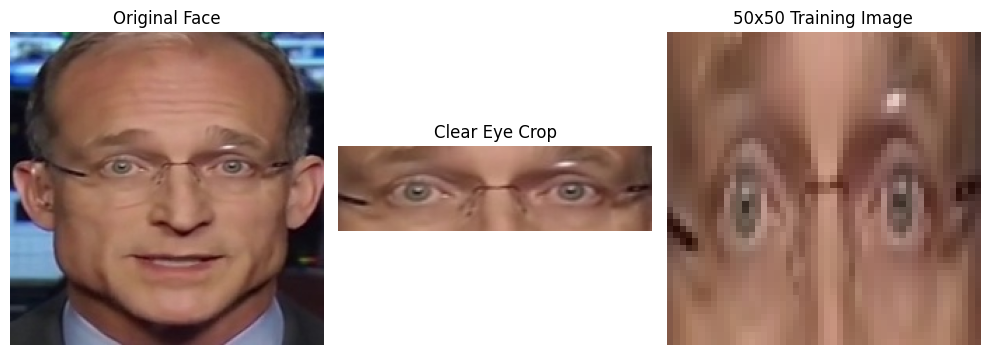

In [37]:
# ==============================
# SHOW CLEAR EYE CROP
# WITHOUT 50x50 RESIZE
# ==============================

import cv2
import matplotlib.pyplot as plt
from mtcnn import MTCNN

# ==============================
# IMAGE PATH
# ==============================
img_path = "/content/drive/MyDrive/Deepfake dataset/FF++C23_ALIGNED_FACES/real/002_370.jpg"

# ==============================
# LOAD IMAGE
# ==============================
img = cv2.imread(img_path)

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# ==============================
# MTCNN
# ==============================
detector = MTCNN()

faces = detector.detect_faces(img_rgb)

if len(faces) == 0:

    print("No face detected")

else:

    face = faces[0]

    keypoints = face["keypoints"]

    left_eye = keypoints["left_eye"]
    right_eye = keypoints["right_eye"]

    # ==============================
    # EYE REGION
    # ==============================
    x1 = min(left_eye[0], right_eye[0]) - 45
    x2 = max(left_eye[0], right_eye[0]) + 45

    y1 = min(left_eye[1], right_eye[1]) - 20
    y2 = max(left_eye[1], right_eye[1]) + 8

    # little lower area
    y2 += 15

    # boundary safety
    x1 = max(0, x1)
    y1 = max(0, y1)

    x2 = min(img.shape[1], x2)
    y2 = min(img.shape[0], y2)

    # ==============================
    # ORIGINAL EYE CROP
    # ==============================
    eye_crop = img_rgb[y1:y2, x1:x2]

    # ==============================
    # 50x50 FOR TRAINING ONLY
    # ==============================
    eye_crop_resized = cv2.resize(eye_crop, (50,50))

    # ==============================
    # SHOW RESULTS
    # ==============================
    plt.figure(figsize=(10,4))

    plt.subplot(1,3,1)
    plt.imshow(img_rgb)
    plt.title("Original Face")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(eye_crop)
    plt.title("Clear Eye Crop")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(eye_crop_resized)
    plt.title("50x50 Training Image")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

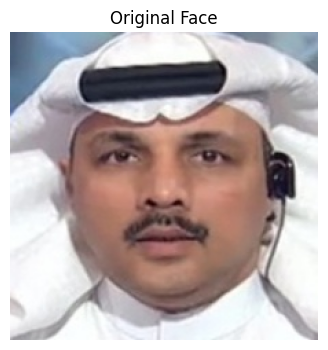

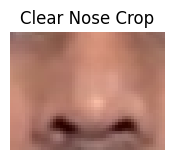

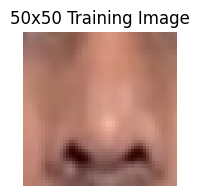

In [32]:
import cv2
import matplotlib.pyplot as plt
from mtcnn import MTCNN

img_path = "/content/drive/MyDrive/Deepfake dataset/FF++C23_FACE_10K_SPLIT/train/real/000_20.jpg"

img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

detector = MTCNN()
faces = detector.detect_faces(img_rgb)

if len(faces) == 0:

    print("No face detected")

else:

    face = max(faces, key=lambda x: x["box"][2] * x["box"][3])

    keypoints = face["keypoints"]

    nose = keypoints["nose"]

    # ==============================
    # NOSE CROP SETTINGS
    # ==============================
    x1 = nose[0] - 25
    x2 = nose[0] + 25

    y1 = nose[1] - 23
    y2 = nose[1] + 15

    # boundary safety
    x1 = max(0, x1)
    y1 = max(0, y1)

    x2 = min(img.shape[1], x2)
    y2 = min(img.shape[0], y2)

    # ==============================
    # NOSE CROP
    # ==============================
    nose_crop = img_rgb[y1:y2, x1:x2]

    # resize for training
    nose_crop_resized = cv2.resize(nose_crop, (50, 50))

    # ==============================
    # SHOW ORIGINAL FACE
    # ==============================
    plt.figure(figsize=(4,4))
    plt.imshow(img_rgb)
    plt.title("Original Face")
    plt.axis("off")
    plt.show()

    # ==============================
    # SHOW CLEAR NOSE CROP
    # ==============================
    plt.figure(figsize=(2,2))
    plt.imshow(nose_crop)
    plt.title("Clear Nose Crop")
    plt.axis("off")
    plt.show()

    # ==============================
    # SHOW 50x50 TRAINING IMAGE
    # ==============================
    plt.figure(figsize=(2,2))
    plt.imshow(nose_crop_resized)
    plt.title("50x50 Training Image")
    plt.axis("off")
    plt.show()

In [ ]:
import os
import cv2
from tqdm import tqdm
from mtcnn import MTCNN

# ==============================
# PATHS
# ==============================
FACE_SPLIT_PATH = "/content/drive/MyDrive/Deepfake dataset/FF++C23_FACE_10K_SPLIT"
NOSE_OUTPUT_PATH = "/content/drive/MyDrive/Deepfake dataset/FF++C23_NOSE_10K_SPLIT"

IMG_SIZE = 50

splits = ["train", "val", "test"]
classes = ["real", "fake"]

# ==============================
# CREATE OUTPUT FOLDERS
# ==============================
for split in splits:
    for cls in classes:
        os.makedirs(os.path.join(NOSE_OUTPUT_PATH, split, cls), exist_ok=True)

# ==============================
# MTCNN
# ==============================
detector = MTCNN()

# ==============================
# NOSE CROP FUNCTION
# ==============================
def crop_nose_from_folder(input_folder, output_folder):

    images = [
        f for f in os.listdir(input_folder)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    saved = 0
    skipped = 0
    failed = 0

    for img_name in tqdm(images):

        img_path = os.path.join(input_folder, img_name)
        save_path = os.path.join(output_folder, img_name)

        # skip already processed images
        if os.path.exists(save_path):
            skipped += 1
            continue

        img = cv2.imread(img_path)

        if img is None:
            failed += 1
            continue

        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        try:
            faces = detector.detect_faces(img_rgb)
        except ValueError as e:
            # Catch the specific ValueError from MTCNN
            # This happens if the convolution operation results in an empty output
            # due to an input that is too small or degenerate for MTCNN's internal layers.
            print(f"Error detecting faces in {img_name}: {e}")
            failed += 1
            continue

        if len(faces) == 0:
            failed += 1
            continue

        face = max(faces, key=lambda x: x["box"][2] * x["box"][3])

        nose = face["keypoints"]["nose"]

        # ==============================
        # FINAL NOSE CROP SETTINGS
        # ==============================
        x1 = nose[0] - 25
        x2 = nose[0] + 25

        y1 = nose[1] - 23
        y2 = nose[1] + 15

        # boundary safety
        x1 = max(0, x1)
        y1 = max(0, y1)
        x2 = min(img.shape[1], x2)
        y2 = min(img.shape[0], y2)

        nose_crop = img_rgb[y1:y2, x1:x2]

        if nose_crop.size == 0:
            failed += 1
            continue

        # resize according to paper: 50x50
        nose_crop = cv2.resize(nose_crop, (IMG_SIZE, IMG_SIZE))

        # RGB to BGR before saving with cv2
        nose_crop_bgr = cv2.cvtColor(nose_crop, cv2.COLOR_RGB2BGR)

        cv2.imwrite(save_path, nose_crop_bgr)

        saved += 1

    print("Saved  :", saved)
    print("Skipped:", skipped)
    print("Failed :", failed)

# ==============================
# RUN ALL SPLITS
# ==============================
for split in splits:
    for cls in classes:

        print(f"\nProcessing: {split}/{cls}")

        input_folder = os.path.join(FACE_SPLIT_PATH, split, cls)
        output_folder = os.path.join(NOSE_OUTPUT_PATH, split, cls)

        crop_nose_from_folder(input_folder, output_folder)

print("\n Nose cropping completed for whole dataset")


Processing: train/real


  1%|          | 42/3999 [00:55<8:49:52,  8.03s/it] 

Error detecting faces in 259_160.jpg: Exception encountered when calling Conv2D.call().

The convolution operation resulted in an empty output. Output shape: (0, 46, 46, 32). This can happen if the input is too small for the given kernel size, strides, dilation rate, and padding mode. Please check the input shape and convolution parameters.

Arguments received by Conv2D.call():
  • inputs=tf.Tensor(shape=(0, 48, 48, 3), dtype=float32)


 16%|█▋        | 659/3999 [03:06<13:34,  4.10it/s]

Error detecting faces in 264_410.jpg: Exception encountered when calling Conv2D.call().

The convolution operation resulted in an empty output. Output shape: (0, 46, 46, 32). This can happen if the input is too small for the given kernel size, strides, dilation rate, and padding mode. Please check the input shape and convolution parameters.

Arguments received by Conv2D.call():
  • inputs=tf.Tensor(shape=(0, 48, 48, 3), dtype=float32)


...

Saved  : 500
Skipped: 0
Failed : 0

Processing: test/real


100%|██████████| 501/501 [01:47<00:00,  4.66it/s]


Saved  : 501
Skipped: 0
Failed : 0

Processing: test/fake


100%|██████████| 500/500 [01:46<00:00,  4.70it/s]

Saved  : 500
Skipped: 0
Failed : 0

✅ Nose cropping completed for whole dataset


In [36]:
import os

# ==============================
# DATASET PATH
# ==============================
dataset_path = "/content/drive/MyDrive/Deepfake dataset/FF++C23_NOSE_10K_SPLIT"

# ==============================
# COUNT IMAGES
# ==============================
total_images = 0

for root, dirs, files in os.walk(dataset_path):

    image_count = len([
        f for f in files
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ])

    if image_count > 0:
        print(f"{root} --> {image_count} images")

    total_images += image_count

# ==============================
# FINAL REPORT
# ==============================
print("\n==============================")
print("TOTAL IMAGES:", total_images)

/content/drive/MyDrive/Deepfake dataset/FF++C23_NOSE_10K_SPLIT/train/real --> 3990 images
/content/drive/MyDrive/Deepfake dataset/FF++C23_NOSE_10K_SPLIT/train/fake --> 3994 images
/content/drive/MyDrive/Deepfake dataset/FF++C23_NOSE_10K_SPLIT/val/real --> 499 images
/content/drive/MyDrive/Deepfake dataset/FF++C23_NOSE_10K_SPLIT/val/fake --> 500 images
/content/drive/MyDrive/Deepfake dataset/FF++C23_NOSE_10K_SPLIT/test/real --> 501 images
/content/drive/MyDrive/Deepfake dataset/FF++C23_NOSE_10K_SPLIT/test/fake --> 500 images

TOTAL IMAGES: 9984


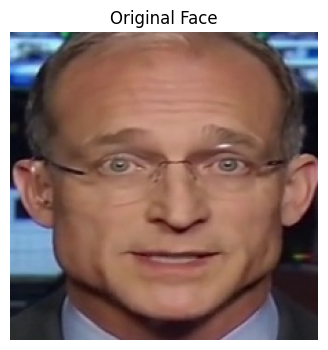

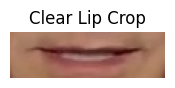

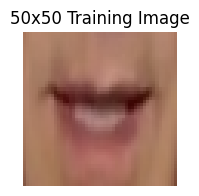

In [59]:
#lip cropping
import cv2
import matplotlib.pyplot as plt
from mtcnn import MTCNN

# ==============================
# IMAGE PATH
# ==============================
img_path = "/content/drive/MyDrive/Deepfake dataset/FF++C23_ALIGNED_FACES/real/002_370.jpg"

# ==============================
# LOAD IMAGE
# ==============================
img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# ==============================
# MTCNN
# ==============================
detector = MTCNN()
faces = detector.detect_faces(img_rgb)

if len(faces) == 0:
    print("No face detected")

else:
    face = max(faces, key=lambda x: x["box"][2] * x["box"][3])
    keypoints = face["keypoints"]

    mouth_left = keypoints["mouth_left"]
    mouth_right = keypoints["mouth_right"]

    # ==============================
    # LIP / MOUTH CROP SETTINGS
    # ==============================
    x1 = mouth_left[0] - 18
    x2 = mouth_right[0] + 18

    y1 = min(mouth_left[1], mouth_right[1]) - 12
    y2 = max(mouth_left[1], mouth_right[1]) + 17

    # boundary safety
    x1 = max(0, x1)
    y1 = max(0, y1)
    x2 = min(img.shape[1], x2)
    y2 = min(img.shape[0], y2)

    # crop mouth
    lip_crop = img_rgb[y1:y2, x1:x2]

    # resize for training
    lip_crop_resized = cv2.resize(lip_crop, (50, 50))

    # ==============================
    # SHOW ONE BY ONE
    # ==============================

    plt.figure(figsize=(4,4))
    plt.imshow(img_rgb)
    plt.title("Original Face")
    plt.axis("off")
    plt.show()

    plt.figure(figsize=(2,2))
    plt.imshow(lip_crop)
    plt.title("Clear Lip Crop")
    plt.axis("off")
    plt.show()

    plt.figure(figsize=(2,2))
    plt.imshow(lip_crop_resized)
    plt.title("50x50 Training Image")
    plt.axis("off")
    plt.show()

In [ ]:
import os
import cv2
from tqdm import tqdm
from mtcnn import MTCNN

# ==============================
# PATHS
# ==============================
FACE_SPLIT_PATH = "/content/drive/MyDrive/Deepfake dataset/FF++C23_FACE_10K_SPLIT"
LIP_OUTPUT_PATH = "/content/drive/MyDrive/Deepfake dataset/FF++C23_LIPS_10K_SPLIT"

IMG_SIZE = 50

splits = ["train", "val", "test"]
classes = ["real", "fake"]

# ==============================
# CREATE OUTPUT FOLDERS
# ==============================
for split in splits:
    for cls in classes:
        os.makedirs(os.path.join(LIP_OUTPUT_PATH, split, cls), exist_ok=True)

# ==============================
# MTCNN
# ==============================
detector = MTCNN()

# ==============================
# LIP CROP FUNCTION
# ==============================
def crop_lips_from_folder(input_folder, output_folder):

    images = [
        f for f in os.listdir(input_folder)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    saved = 0
    skipped = 0
    failed = 0

    for img_name in tqdm(images):

        img_path = os.path.join(input_folder, img_name)
        save_path = os.path.join(output_folder, img_name)

        # skip already processed images
        if os.path.exists(save_path):
            skipped += 1
            continue

        img = cv2.imread(img_path)

        if img is None:
            failed += 1
            continue

        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        try:
            faces = detector.detect_faces(img_rgb)
        except ValueError as e:
            # Catch the specific ValueError from MTCNN
            # This happens if the convolution operation results in an empty output
            # due to an input that is too small or degenerate for MTCNN's internal layers.
            print(f"Error detecting faces in {img_name}: {e}")
            failed += 1
            continue

        if len(faces) == 0:
            failed += 1
            continue

        face = max(faces, key=lambda x: x["box"][2] * x["box"][3])
        keypoints = face["keypoints"]

        mouth_left = keypoints["mouth_left"]
        mouth_right = keypoints["mouth_right"]

        # ==============================
        # FINAL LIP CROP SETTINGS
        # ==============================
        x1 = mouth_left[0] - 18
        x2 = mouth_right[0] + 18

        y1 = min(mouth_left[1], mouth_right[1]) - 12
        y2 = max(mouth_left[1], mouth_right[1]) + 17

        # boundary safety
        x1 = max(0, x1)
        y1 = max(0, y1)
        x2 = min(img.shape[1], x2)
        y2 = min(img.shape[0], y2)

        lip_crop = img_rgb[y1:y2, x1:x2]

        if lip_crop.size == 0:
            failed += 1
            continue

        # resize to 50x50
        lip_crop = cv2.resize(lip_crop, (IMG_SIZE, IMG_SIZE))

        # RGB to BGR before saving with cv2
        lip_crop_bgr = cv2.cvtColor(lip_crop, cv2.COLOR_RGB2BGR)

        cv2.imwrite(save_path, lip_crop_bgr)

        saved += 1

    print("Saved  :", saved)
    print("Skipped:", skipped)
    print("Failed :", failed)

# ==============================
# RUN ALL SPLITS
# ==============================
for split in splits:
    for cls in classes:

        print(f"\nProcessing: {split}/{cls}")

        input_folder = os.path.join(FACE_SPLIT_PATH, split, cls)
        output_folder = os.path.join(LIP_OUTPUT_PATH, split, cls)

        crop_lips_from_folder(input_folder, output_folder)

print("\n Lip cropping completed for whole dataset")


Processing: train/real


  1%|          | 42/3999 [00:55<8:44:09,  7.95s/it] 

Error detecting faces in 259_160.jpg: Exception encountered when calling Conv2D.call().

The convolution operation resulted in an empty output. Output shape: (0, 46, 46, 32). This can happen if the input is too small for the given kernel size, strides, dilation rate, and padding mode. Please check the input shape and convolution parameters.

Arguments received by Conv2D.call():
  • inputs=tf.Tensor(shape=(0, 48, 48, 3), dtype=float32)


 17%|█▋        | 660/3999 [03:07<09:52,  5.63it/s]

Error detecting faces in 264_410.jpg: Exception encountered when calling Conv2D.call().

The convolution operation resulted in an empty output. Output shape: (0, 46, 46, 32). This can happen if the input is too small for the given kernel size, strides, dilation rate, and padding mode. Please check the input shape and convolution parameters.

Arguments received by Conv2D.call():
  • inputs=tf.Tensor(shape=(0, 48, 48, 3), dtype=float32)


...

Saved  : 500
Skipped: 0
Failed : 0

Processing: test/real


100%|██████████| 501/501 [01:47<00:00,  4.65it/s]


Saved  : 501
Skipped: 0
Failed : 0

Processing: test/fake


100%|██████████| 500/500 [01:46<00:00,  4.71it/s]

Saved  : 500
Skipped: 0
Failed : 0

✅ Lip cropping completed for whole dataset


In [ ]:
import os
import cv2
from tqdm import tqdm
from mtcnn import MTCNN

FRAME_PATH = "D:/frames"
OUTPUT_PATH = "D:/faces"

detector = MTCNN()

real_out = os.path.join(OUTPUT_PATH, "real")
fake_out = os.path.join(OUTPUT_PATH, "fake")

os.makedirs(real_out, exist_ok=True)
os.makedirs(fake_out, exist_ok=True)

def extract_faces(input_folder, output_folder):
    for img_name in tqdm(os.listdir(input_folder)):
        img_path = os.path.join(input_folder, img_name)

        image = cv2.imread(img_path)
        if image is None:
            continue

        try:
            rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            results = detector.detect_faces(rgb)

            if len(results) == 0:
                continue

            face = max(results, key=lambda x: x['box'][2]*x['box'][3])
            x, y, w, h = face['box']

            x, y = max(0, x), max(0, y)

            # margin
            margin = 20
            x1 = max(0, x - margin)
            y1 = max(0, y - margin)
            x2 = min(image.shape[1], x + w + margin)
            y2 = min(image.shape[0], y + h + margin)

            crop = image[y1:y2, x1:x2]

            if crop.size == 0:
                continue

            crop = cv2.resize(crop, (224, 224))

            #  KEEP ORIGINAL NAME
            cv2.imwrite(os.path.join(output_folder, img_name), crop)

        except:
            continue

# RUN
extract_faces(os.path.join(FRAME_PATH, "real"), real_out)
extract_faces(os.path.join(FRAME_PATH, "fake"), fake_out)

print("✅ Face extraction done")

100%|██████████| 2500/2500 [07:45<00:00,  5.37it/s]

✅ Face extraction done


In [ ]:
import os

real_path = "D:/faces/real"
fake_path = "D:/faces/fake"

pairs = []

real_images = os.listdir(real_path)
fake_images = os.listdir(fake_path)

for real_img in real_images:
    try:
        # Expected format for real images: real_VIDEOID_FRAMEID.jpg (e.g., real_012_8.jpg)
        real_name_parts = real_img.replace(".jpg", "").split("_")
        if len(real_name_parts) != 3 or real_name_parts[0] != 'real':
            # Skip if filename format is not as expected
            continue

        real_vid_id = real_name_parts[1]   # Extracts '012' from 'real_012_8'
        real_frame_id = real_name_parts[2] # Extracts '8' from 'real_012_8'

        for fake_img in fake_images:
            # Expected format for fake images: fake_VIDEOID_MANIPID_FRAMEID.jpg (e.g., fake_221_206_5.jpg)
            fake_name_parts = fake_img.replace(".jpg", "").split("_")
            if len(fake_name_parts) != 4 or fake_name_parts[0] != 'fake':
                # Skip if filename format is not as expected
                continue

            fake_vid_id = fake_name_parts[1]    # Extracts '221' from 'fake_221_206_5'
            fake_frame_id = fake_name_parts[3]  # Extracts '5' from 'fake_221_206_5'

            # Match logic: original video ID and frame ID must be the same
            if real_vid_id == fake_vid_id and real_frame_id == fake_frame_id:
                pairs.append((real_img, fake_img))

    except Exception as e:
        # In case of any unexpected filename format, skip the image
        continue

print("✅ Total pairs found:", len(pairs))
print("Sample pairs:", pairs[:5])

FileNotFoundError: [Errno 2] No such file or directory: 'D:/faces/real'

In [ ]:
import os
import shutil

paired_path = "D:/paired_dataset"

os.makedirs(f"{paired_path}/real", exist_ok=True)
os.makedirs(f"{paired_path}/fake", exist_ok=True)

for i, (r, f) in enumerate(pairs):
    shutil.copy(os.path.join(real_path, r),
                os.path.join(paired_path, "real", f"pair_{i}.jpg"))

    shutil.copy(os.path.join(fake_path, f),
                os.path.join(paired_path, "fake", f"pair_{i}.jpg"))

print("✅ Paired dataset created")

✅ Paired dataset created


In [ ]:
!ls /content

D:  drive  frames  sample_data


In [ ]:
!zip -r faces_dataset.zip "/content/D:/paired_dataset"

updating: content/D:/paired_dataset/ (stored 0%)
updating: content/D:/paired_dataset/real/ (stored 0%)
updating: content/D:/paired_dataset/real/pair_1898.jpg (deflated 1%)
updating: content/D:/paired_dataset/real/pair_1284.jpg (deflated 2%)
updating: content/D:/paired_dataset/real/pair_472.jpg (deflated 2%)
updating: content/D:/paired_dataset/real/pair_1329.jpg (deflated 2%)
updating: content/D:/paired_dataset/real/pair_2061.jpg (deflated 1%)
updating: content/D:/paired_dataset/real/pair_1474.jpg (deflated 1%)
updating: content/D:/paired_dataset/real/pair_14.jpg (deflated 1%)
updating: content/D:/paired_dataset/real/pair_788.jpg (deflated 1%)
updating: content/D:/paired_dataset/real/pair_964.jpg (deflated 1%)
updating: content/D:/paired_dataset/real/pair_2156.jpg (deflated 1%)
updating: content/D:/paired_dataset/real/pair_1709.jpg (deflated 1%)
updating: content/D:/paired_dataset/real/pair_1037.jpg (deflated 1%)
updating: content/D:/paired_dataset/real/pair_1706.jpg (deflated 1%)
updat

In [ ]:
from google.colab import files
files.download("paired_dataset_dataset.zip")

FileNotFoundError: Cannot find file: paired_dataset_dataset.zip

In [ ]:
import shutil

folder_path = "/content/D:/paired_dataset"   # change if your path is different
output_zip = "/content/paired_dataset.zip"

shutil.make_archive("/content/paired_dataset", 'zip', folder_path)

'/content/paired_dataset.zip'

In [ ]:
from google.colab import files

files.download("/content/paired_dataset.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import shutil

folder_path = "/content/D:/frames"   # change if your path is different
output_zip = "/content/frames.zip"

shutil.make_archive("/content/frames", 'zip', folder_path)

'/content/frames.zip'

In [ ]:
from google.colab import files

files.download("/content/frames.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>